# Explore here

**Airbnb en Nueva York**
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

In [7]:
# Your code here
from sqlalchemy.orm import declarative_base
from sqlalchemy import String
from sqlalchemy.orm import Mapped, mapped_column

Base = declarative_base()

class ExampleModel(Base):
    __tablename__ = 'example_table'
    id: Mapped[int] = mapped_column(primary_key=True)
    username: Mapped[str] = mapped_column(unique=True)

## 1. Definición del problema: 
*Se identifica una necesidad que se trata de solucionar utilizando Machine Learning.*

Dataset de alquileres de Airbnb en Nueva York (2019).

**Objetivo:** analizar qué variables influyen en el precio de un alojamiento.

**Variable target:** `price`

**Variables seleccionadas:** `neighbourhood_group`, `neighbourhood`, `room_type`, 
`minimum_nights`, `availability_365`, `number_of_reviews`, 
`calculated_host_listings_count`, `last_review`

**Variables descartadas:** `name`, `host_name`, `id`, `host_id`, `latitude` y `longitude`:  no aportan nada al objetivo planteado

**Posibles problemas:** nulos, outliers, variables categóricas, 
last_review requiere transformación

## 2. Obtención de datos
Identificar y acceder a las fuentes de datos relevantes.Recopilar los datos necesarios para el proyecto. Organizar y almacenar los datos de manera adecuada.

In [8]:
import pandas as pd
df = pd.read_csv("../data/raw/AB_NYC_2019.csv")

In [9]:
#exploración del df
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [10]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

En las variables de `name`hay 16 elementos nulos, en `host_name`: 21, y en `last_review`y `reviews_per_month`hay 10052. Las dos primeras y la última no nos preocupan, dado que son variables que hemos descartado, sin embargo, "last_review" era una variable que habiamos seleccionado al principio y tiene una gran cantidad de valores nulos

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

Con esta función podemos ver qué tipo son los elementos de las variables, comprobamos que muchas de las columnas son `str`, es decir, texto.

In [12]:
df.shape #Cuántas columnas y filas tiene nuestro DataFrame

(48895, 16)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['neighbourhood_group'].unique()

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

In [15]:
df['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [16]:
df['neighbourhood'].unique()

<StringArray>
[        'Kensington',            'Midtown',             'Harlem',
       'Clinton Hill',        'East Harlem',        'Murray Hill',
 'Bedford-Stuyvesant',     'Hell's Kitchen',    'Upper West Side',
          'Chinatown',
 ...
     'Fort Wadsworth',           'Rosebank',          'Unionport',
         'Mill Basin',      'Arden Heights',        'Bull's Head',
           'New Dorp',          'Rossville',       'Breezy Point',
        'Willowbrook']
Length: 221, dtype: str

In [17]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


El precio minimo es 0 (este dato es extraño) y el máximo 10000 y el precio medio es de 152.720687

Hay una media de 7 noches minimas, siendo 1 el minimo y 1250 el máximo (este dato parece raro)

El máximo de disponibilidad es 365, el minimo 0 y la media de 112.781327

Hay 23 reviews de media, con 629 de máxima y 1 de minima; y por mes son 23.274466 reviews, con 0.01  de minima y 58.5 de máxima

In [18]:
df[df["price"] == 0].shape[0]

11

In [19]:
df[df["minimum_nights"] > 365].shape[0]

14

**En base a todos estos datos, decidimos lo siguiente:**

- Descartamos una de las variables en principio elegidas: `last_review`. Dado que hemos visto que tiene demasiados valores nulos y la variables de `number_of_reviews`nos dan información muy similar. Asi como `neighbourhood`, al tener 221 clasificaciones, que para el modelo de ML serian demasiadas, y `neighbourhood_group` nos dará la información suficiente para responder los objetivos
- Existen 11 registros de `price` que son = a 0 y 14 registros de `minium_nights` mayores de 365 (un año), lo que no tiene sentido porque no se alquilarian por 0€ y el minimo de noches no debería ser mayor a un año, no tiene sentido. Por lo que aunque sean pocos, los eliminaremos.
- No tenemos duplicados en el dataset. 

## 3. Preparación de datos
**Limpieza de datos**
- Eliminar columnas que descartamos:'id', 'name', 'host_id', 'last_review', 'longitude', 'latitude'
- Eliminar filas con precio = 0
- Eliminar filas con minimum_nights > 365

In [20]:
df = df.drop(['id', 'name', 'host_name', 'host_id', 'last_review', 'longitude', 'latitude', 'neighbourhood'], axis=1)
df = df[df['price'] != 0]
df = df[df['minimum_nights'] <= 365]

In [21]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0) #rellenamos los nulos con 0 porque siguiendo la lógica, si no hay reviews significa que tiene 0 reviews. Y no eliminmos esta columna porque nos da información valiosa como si el alojamiento es nuevo por ejemplo, al no tener reviews

verificar cómo ha quedado el data set

In [22]:
df.shape

(48870, 8)

In [23]:
df.isnull().sum() #Revisamos los valores nulos

neighbourhood_group               0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

**Análisis univariado (distribuciones de cada variable)**

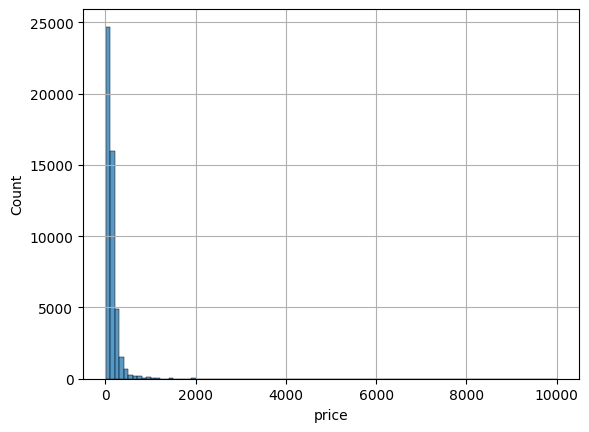

In [24]:
#Historiograma para ver la distribución del precio
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins=100)


plt.grid ()
plt.show()

Los precios de los alojamientos se distribuyen escalonadamente. Estando gran parte de los alojamientos dentro de un rango de 0 a 500€, aunque sobretodo de 0 a 200€. A partir de 500€ existen muy pocos registros, por lo que hemos tenido que acortar el grafico para que se pueda leer mejor. 

Esta forma de gráfica donde hay muchísimos valores bajos y pocos valores muy altos se llama **distribución sesgada a la derecha (o right-skewed)**. Es muy típica en variables de precio.

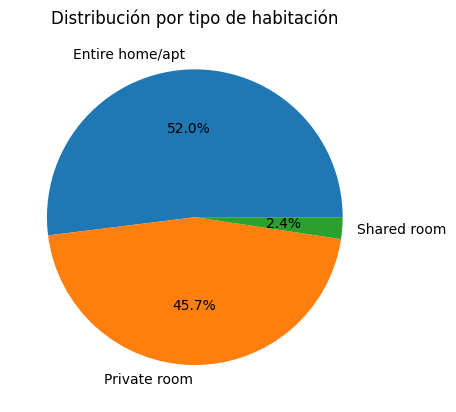

In [25]:
df['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución por tipo de habitación')
plt.show()

**Tipo de habitación**: Más de la mitad de los alojamientos se clasifica como "Entire home/apt". El 45% como "Private room" y solo el 2,4% como habitación compartida

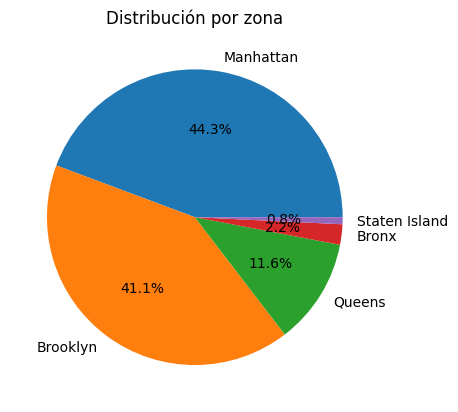

In [26]:
df['neighbourhood_group'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución por zona')
plt.show()

En este dataset de alojamientos en New York la mayor parte se distribuye entre Manhattan (44.3%) y Brooklyn (41.1%), tiene sentido ya que son los barrios más turísticos de Nueva York. 

Queens estaría en el 3º barrio con más alojamientos con un 11,6% y donde menos hay es en Staten Island (0.8%) y Bronx (2.2%)

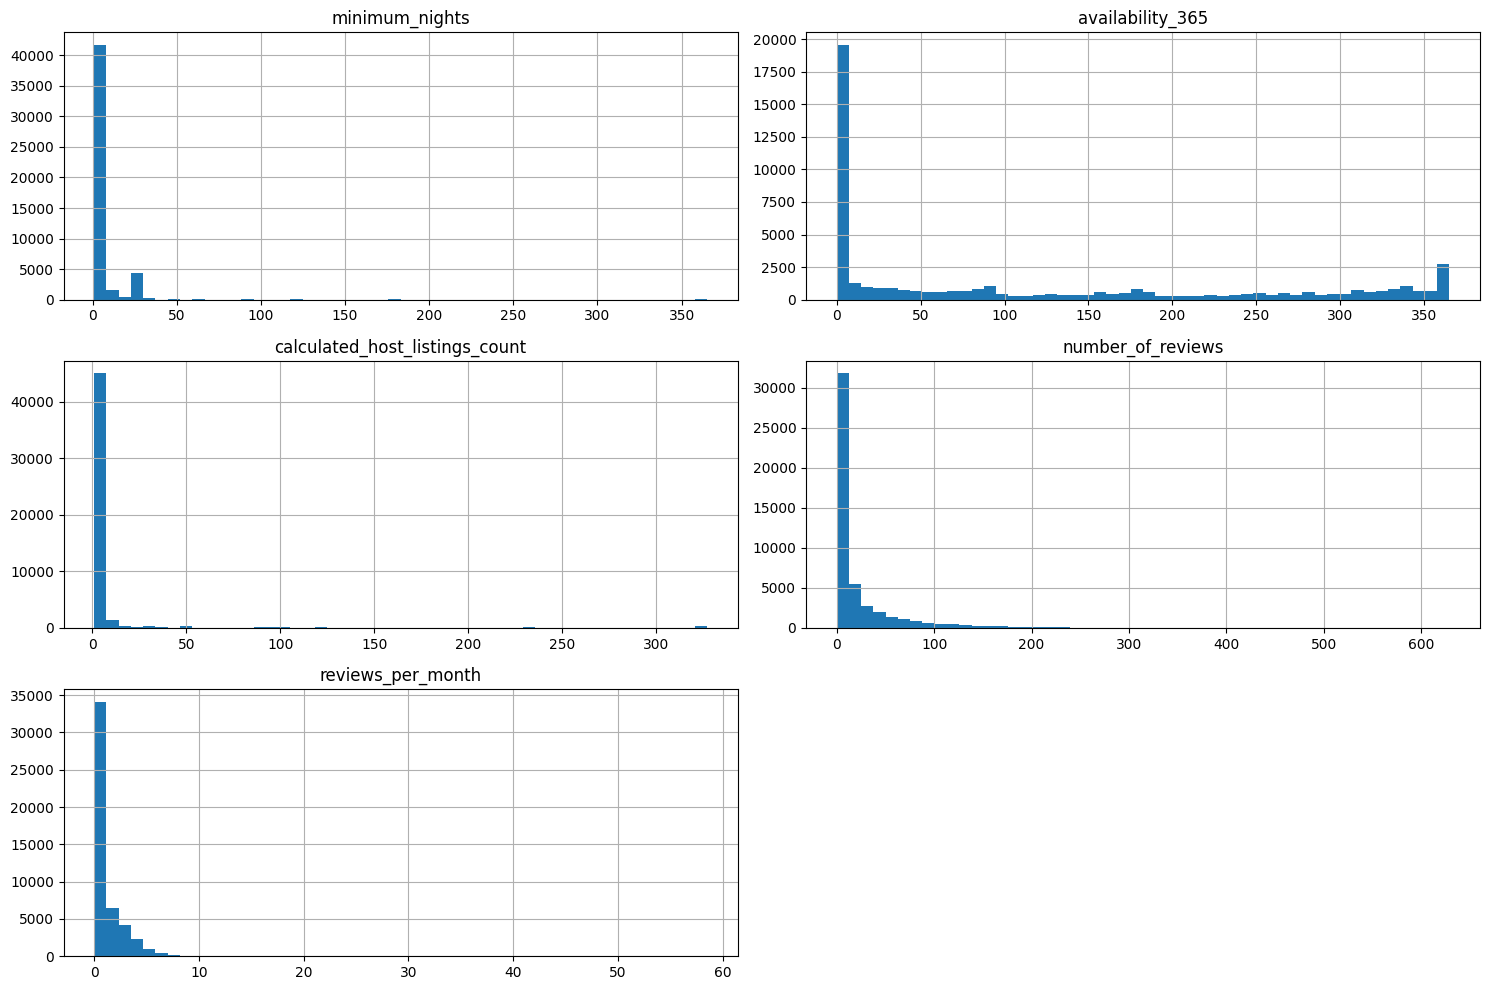

In [27]:
#Creamos historiogramas para el resto de las variables que nos quedan para interpretarlas

resto_var = ['minimum_nights', 'availability_365', 'calculated_host_listings_count', 'number_of_reviews', 'reviews_per_month'] 
df[resto_var].hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

Estos 5 gráficos siguen una distribución bastante similar. La mayor parte de los datos se distribuyen al principio.
- Avilability_365: Tiene los datos más distribuidos equitativamente en el centro de la gráfica, aunque existen picos en los extremos, sobretodo al principio, mostrando alojamientos que no tienen ningún día disponible, probablemente están inactivos o totalmente ocupados. Y el pico al final (365) son los que están disponibles todo el año.
- Minimum_nights: observamos que la mayor parte de los datos están entre 0-50. Exisitiendo outliers repartidos en los dato mayores a 100 
- Number_of_reviews: en general los alojamientos tienen pocas reseñas. La gran parte de los datos se reparten en el rango de 0-50. y de 50-100 disminuyen de forma bastante equitativa
- Reviews_per_month: los datos se agrupan entre 0-10. Viendo el numero de reviews que hay, que el mes tiene 30-31 dias. Son datos bastante aceptables. 

**Análisis multivariado** ¿Cómo se relacionan las variables?

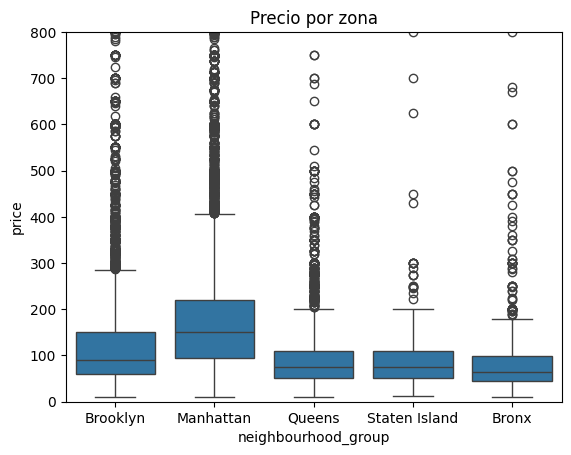

In [28]:
#Relación del precio por zona
sns.boxplot(data=df, x='neighbourhood_group', y='price')
plt.ylim (0,800)

plt.title('Precio por zona')
plt.show()

Este boxplot nos permite ver a simplevista que existen gran cantidad de outliers con precios de hasa 10000, muy separados de la media. Limitando un poco el gráfico para poder obserarlo mejor, vemos que los precios más elevados están en Manhattan y los más baratos en el Bronx

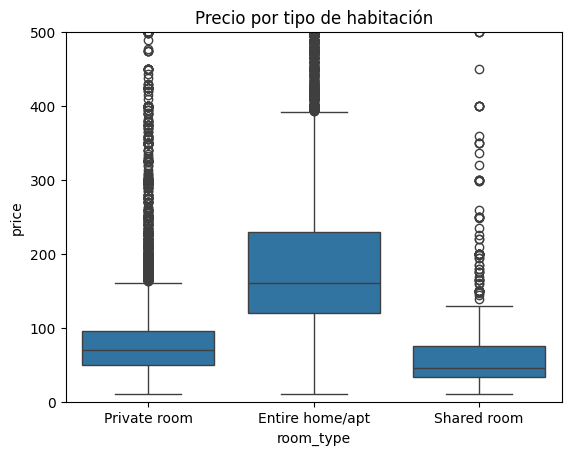

In [29]:
sns.boxplot(data=df, x='room_type', y='price')
plt.ylim (0,500)

plt.title('Precio por tipo de habitación')
plt.show()

Si es un apartamento o cassa entera es más caro en relación a una habitación compartida (tiene mucho sentido). La jerarquía es clara: Entire home > Private room > Shared room 

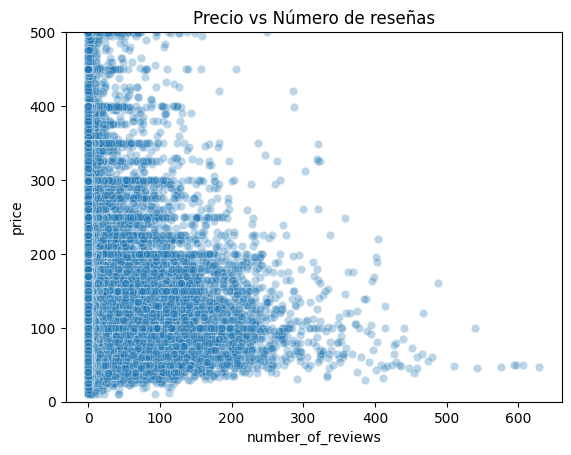

In [30]:
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.3)
plt.ylim(0, 500)
plt.title('Precio vs Número de reseñas')
plt.show()

El número de reselas se arupa claramente en la parte de abajo del gráfico, siendo los alojamientos más baratos los uqe más reseñas acumulan. Puede significar porque tiene más cantidad de reservar, aunque es algo que deducimos, no podemos afirmar 

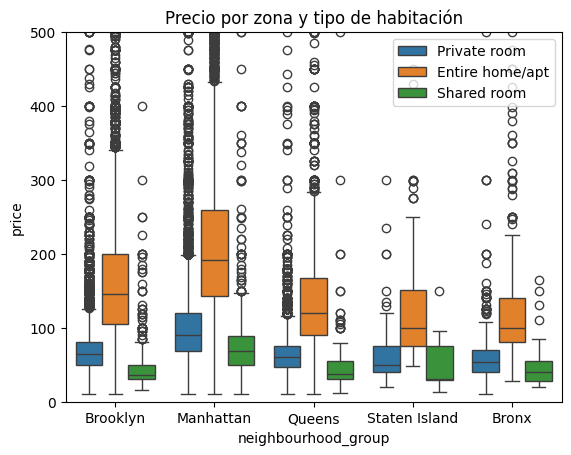

In [31]:
sns.boxplot(data=df, x='neighbourhood_group', y='price', hue='room_type')
plt.ylim(0, 500)
plt.title('Precio por zona y tipo de habitación')
plt.legend(loc='upper right')
plt.show()

En Manhattan, el precio entre los tres tipos de vivienda es más diferenciado. A diferencia de en State Island que tiene valores más juntos, al ser la zona más barata y menos turística. Además, en este grupo de barrio la cantidad de habitaciones compartidas es bastante alta, mayor que la habitación privada (que como antes hemos visto la jerarquia general era departamento completo>hab privada>hab compartida). En Brooklyn es donde menos cantidad de habitaciones compartidas hay. 

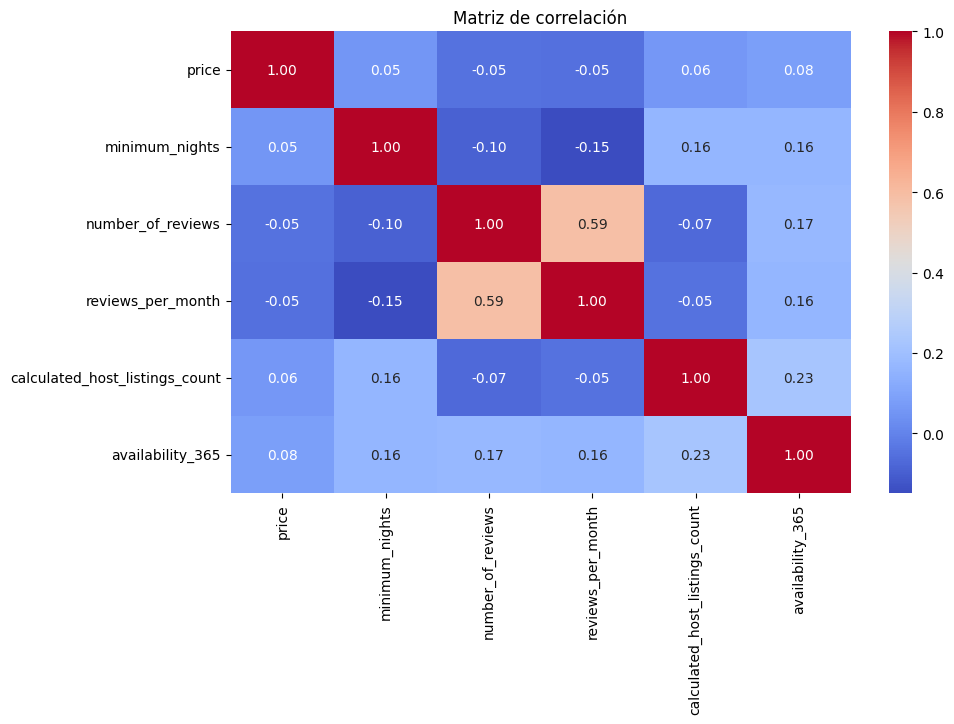

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

Aqui vemos que las ninguna variable numérica tiene correlación fuerte con el precio, por lo que  necesitamos las variables categóricas transformadas para explicar bien el precio.

Otras relaciones a tener en cuenta: 
- calculated_host_listings_count vs minimum_nights (0.16) — los hosts con más propiedades tienden a pedir un mínimo de noches ligeramente mayor. Probablemente porque son negocios más profesionalizados que prefieren reservas largas para reducir rotación.
- calculated_host_listings_count vs availability_365 (0.23) — tiene sentido también: un host profesional con muchas propiedades las mantiene más disponibles durante el año para maximizar ocupación.
- number_of_reviews vs minimum_nights (-0.15) — ligera correlación negativa: cuanto mayor es el mínimo de noches, menos reseñas acumula. Lógico, porque si pides 30 noches mínimo, tendrás muchas menos reservas y por tanto menos reseñas.

En general, estas correlaciones confirman que hay una diferencia entre hosts profesionales (muchas propiedades, más disponibilidad, mínimos más altos) y hosts particulares (pocas propiedades, menos disponibilidad, más reseñas).

**Transformaciones**

Las variables categóricas no las pueden procesar los modelos de ML directamente. Asi que las transformamos en números

In [33]:
room_mapping = {
    'Shared room': 0,
    'Private room': 1,
    'Entire home/apt': 2
}

df['room_type'] = df['room_type'].map(room_mapping)

In [34]:
df['room_type'].unique() #comprobar

array([1, 2, 0])

In [35]:
df.shape

(48870, 8)

In [36]:
df.columns #comprobar

Index(['neighbourhood_group', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='str')

In [37]:
df = pd.get_dummies(df, columns=['neighbourhood_group']) #crea una columna nueva por cada categoría y pone un 1 donde corresponde y 0 en el resto. Así el modelo puede entender la información sin que haya un orden implícito entre las categorías

In [38]:
df.shape

(48870, 12)

**Quitar outliers**

In [39]:
Q1 = df['price'].quantile(0.25) #el valor que deja el 25% de los datos por debajo
Q3 = df['price'].quantile(0.75) #el valor que deja el 75% de los datos por debajo
IQR = Q3 - Q1 #rango del "medio" de los datos

df = df[df['price'] <= Q3 + 1.5 * IQR] #cualquier valor que esté muy por encima de Q3 es sospechosamente alto. el 1.5 es un factor estándar en estadística 

In [40]:
df.shape

(45899, 12)

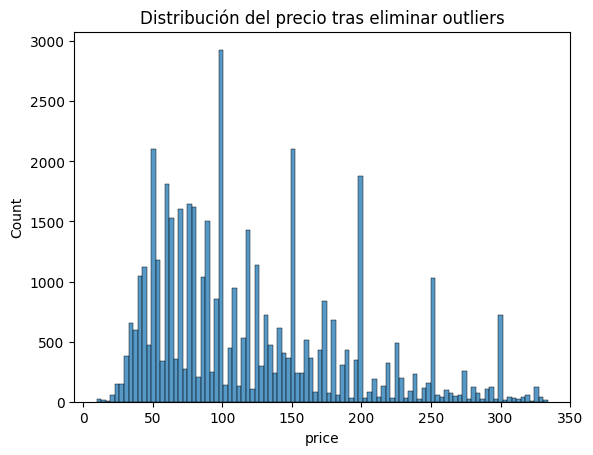

In [41]:
#Representación del precio después de elimanr los outliers
sns.histplot(df['price'], bins=100)
plt.title('Distribución del precio tras eliminar outliers')
plt.show()

Ahora se ve claramente que:

- La mayoría de alojamientos están entre 50$ y 150$
- El pico más alto está en 100$ — probablemente porque los hosts redondean al número "psicológico"
- A partir de 200$ los datos van disminuyendo progresivamente
- El máximo ahora es ~350$ en vez de 10.000$

In [42]:
Q1 = df['minimum_nights'].quantile(0.25)
Q3 = df['minimum_nights'].quantile(0.75)
IQR = Q3 - Q1

df = df[df['minimum_nights'] <= Q3 + 1.5 * IQR]

In [43]:
df = df[df['calculated_host_listings_count'] <= 10] #aplicamos un límite manual para calculated_host_listings_count. Porque si hacemos lo del IQ nos elimina de forma muy agresiva (solo deja 1,2 o 3)


In [44]:
df.shape

(39057, 12)

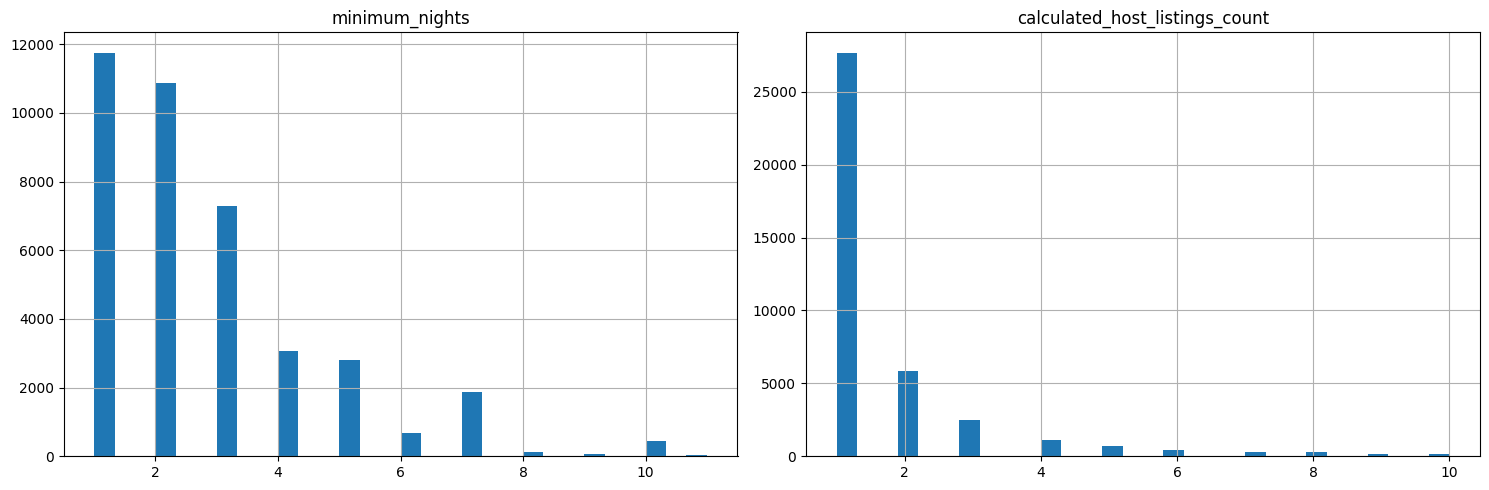

In [45]:
no_outliers = ['minimum_nights','calculated_host_listings_count'] 
df[no_outliers].hist(bins=30, figsize=(15,5))
plt.tight_layout()
plt.show()

- La mayoría de alojamientos piden entre 1-3 noches mínimo, que es lo más normal en Airbnb.
- La mayoría tiene 1-2 propiedades pero se conservan hosts con hasta 10, que es razonable.


**Selección de características**

X — las variables que usaremos para predecir (features)

y — la variable que queremos predecir (target = price)

In [46]:
X = df.drop('price', axis=1)
y = df['price']

In [47]:
X.shape #comprobar

(39057, 11)

**División train y test**

- Train (entrenamiento): los datos con los que el modelo aprende. Normalmente el 80%
- Test (prueba): datos que el modelo nunca ha visto, con los que evaluamos si realmente aprendió. Normalmente el 20%

In [51]:
df.to_csv('../data/processed/AB_NYC_2019_processed.csv', index=False, encoding='utf-8') #guardar el dataset procesado

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #random_state=42 asegura que la división sea siempre la misma cada vez que ejecutes el código — sin eso, cada vez se dividiría de forma diferente y los resultados no serían reproducibles.

scaler = StandardScaler() #escalado de las características para que el modelo no se vea sesgado por la escala de las variables. El escalado es especialmente importante para modelos que se basan en la distancia entre puntos (como KNN o SVM) o que utilizan regularización (como Ridge o Lasso). Al escalar, transformamos los datos para que tengan una media de 0 y una desviación estándar de 1, lo que ayuda a que el modelo aprenda de manera más eficiente y a mejorar su rendimiento.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(31245, 11)
(7812, 11)
